# Анализ транзакционных данных. Поиск ассоциативных правил и выявление скрытых структур в данных.

**Цель работы:**  
Проанализировать транзакции с помощью выявления частых наборов, построения ассоциативных правил и с использованием методов линейной и нелинейной проекции.

**Задачи:**  
1. Загрузить и изучить данные.  
2. Построить матрицу транзакций.  
3. Найти частые наборы (min_support=0.06, max размер = 4) и найти самый большой частый набор, содержащий товар `turkey`. 
4. Сгенерировать ассоциативные правила (min_confidence=0.1) и найти правило с максимальным лифтом, где `turkey` в левой части. 
5. Визуализировать граф для двухместных правил.
6. Рассчитать меры центральности HITS (Hubs and Authorities) для полученного графа.
7. С помощью метода NMF (Non-negative Matrix Factorization) построить линейную проекцию набора данных на плоскость (2 компоненты).
8. С помощью метода t-SNE (t-Distributed Stochastic Neighbor Embedding) построить нелинейную проекцию набора данных на плоскость. 
9. Из исходной матрицы отобрать 7 независимых переменных с использованием метода VarClus (кластеризация переменных).

In [34]:
#импорт библиотек
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import NMF
from sklearn.manifold import TSNE
from varclushi import VarClusHi


## 1. Загрузка данных

In [35]:
df = pd.read_csv('TRANSACTION.csv')
df = df.drop('TIME', axis=1)
df.head()

,CUSTOMER,PRODUCT
0,0,hering
1,0,corned_b
2,0,olives
3,0,ham
4,0,turkey


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7007 entries, 0 to 7006
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   CUSTOMER  7007 non-null   int64 
 1   PRODUCT   7007 non-null   object
dtypes: int64(1), object(1)
memory usage: 109.6+ KB


In [37]:
unique_customers = df['CUSTOMER'].nunique()
unique_products = df['PRODUCT'].nunique()
print(f"Количество уникальных покупателей: {unique_customers}")
print(f"Количество уникальных товаров: {unique_products}")

Количество уникальных покупателей: 1001
Количество уникальных товаров: 20


## 2. Построение матрицы транзакций

In [38]:
basket = pd.crosstab(df["CUSTOMER"], df["PRODUCT"])
def encode_units(x):
    return 1 if x >= 1 else 0
basket_sets = basket.applymap(encode_units)
basket_sets.head()

PRODUCT,apples,artichok,avocado,baguette,bordeaux,bourbon,chicken,coke,corned_b,cracker,ham,heineken,hering,ice_crea,olives,peppers,sardines,soda,steak,turkey
CUSTOMER,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,1,0,0,1,0,1,0,1,1,1,0,0,0,0,1
1,0,0,0,1,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,0
2,0,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,1
3,0,0,0,0,0,1,0,1,0,0,1,0,0,1,1,1,0,0,0,1
4,1,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1


Получаем матрицу транзакций, где каждая строка - клиент, столбец - продукт. Значение ячейки = 1, если клиент купил продукт, иначе = 0.

## 3. Поиск частых наборов с помощью FP-Growth

In [39]:
frequent_itemsets = fpgrowth(basket_sets, min_support=0.06, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.485514,(hering)
1,0.472527,(olives)
2,0.402597,(bourbon)
3,0.390609,(corned_b)
4,0.312687,(ice_crea)
...,...,...
320,0.112887,"(cracker, bourbon, chicken)"
321,0.061938,"(chicken, bourbon, heineken)"
322,0.100899,"(corned_b, cracker, chicken)"
323,0.097902,"(corned_b, bourbon, chicken)"


Алгоритм FP-Growth строит дерево в оперативной памяти компьютера, анализирует его, находит все частые связки, помещает в переменную `frequent_itemsets` и удаляет дерево, как только закончит расчеты.

In [40]:
# ограничим размер набора до 4
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
result_n2 = frequent_itemsets[frequent_itemsets['length'] <= 4]
result_n2

,support,itemsets,length
0,0.485514,(hering),1
1,0.472527,(olives),1
2,0.402597,(bourbon),1
3,0.390609,(corned_b),1
4,0.312687,(ice_crea),1
...,...,...,...
320,0.112887,"(cracker, bourbon, chicken)",3
321,0.061938,"(chicken, bourbon, heineken)",3
322,0.100899,"(corned_b, cracker, chicken)",3
323,0.097902,"(corned_b, bourbon, chicken)",3


В результате найдено 315 частых наборов данных, удовлетворяющих поставленным условиям, и соответствующая им величина поддержки (support).

In [41]:
# самый большой частый набор, содержащий индейку
turkey_sets = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: 'turkey' in x)]
turkey_sets.loc[turkey_sets['length'].idxmax()]

support                                    0.101898
itemsets    (turkey, hering, ham, olives, corned_b)
length                                            5
Name: 99, dtype: object

## 4. Построение ассоциативных правил с порогом на достоверность 10%

In [42]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
print(f"Сгенерировано правил: {len(rules)}")
rules.head()

Сгенерировано правил: 1918


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(hering),(heineken),0.485514,0.599401,0.287712,0.592593,0.988642,1.0,-0.003305,0.983289,-0.021842,0.360902,-0.016995,0.536296
1,(heineken),(hering),0.599401,0.485514,0.287712,0.480000,0.988642,1.0,-0.003305,0.989395,-0.027879,0.360902,-0.010718,0.536296
2,(hering),(cracker),0.485514,0.487512,0.200799,0.413580,0.848348,1.0,-0.035895,0.873926,-0.257861,0.260026,-0.144262,0.412733
3,(cracker),(hering),0.487512,0.485514,0.200799,0.411885,0.848348,1.0,-0.035895,0.874805,-0.258607,0.260026,-0.143112,0.412733
4,"(hering, cracker)",(heineken),0.200799,0.599401,0.162837,0.810945,1.352927,1.0,0.042478,2.118960,0.326403,0.255486,0.528070,0.541306


In [43]:
#правило с максимальным лифтом, где turkey в левой части
turkey_rules = rules[rules['antecedents'].apply(lambda x: 'turkey' in x)]
turkey_rules.loc[turkey_rules['lift'].idxmax()]


antecedents                        (coke, turkey)
consequents           (bourbon, olives, ice_crea)
antecedent support                       0.118881
consequent support                       0.107892
support                                  0.093906
confidence                               0.789916
lift                                     7.321351
representativity                              1.0
leverage                                  0.08108
conviction                               4.246434
zhangs_metric                            0.979905
jaccard                                  0.706767
certainty                                0.764508
kulczynski                               0.830143
Name: 491, dtype: object

Для продукта turkey (индейка) было выявлено сильное ассоциативное правило: {coke, turkey} -> {ice_crea, olives, bourbon}. Данное правило обладает высокой достоверностью (Confidence 79%), что говорит о стабильности данной модели потребления. Показатель Lift 7.32 подтверждает наличие мощной связи между товарами. Это означает, что покупка колы и индейки увеличивает вероятность покупки набора (мороженое, оливки, бурбон) в 7.3 раза относительно случайного выбора.

## 5. Построение оринетированного графа для двухместных правил
Его вершины - элементы, их размер равен поддержке элемента (item support), дуги – импликации (ориентированы в направлении от условия к следствию), веса дуг (их толщина) – достоверности.


In [44]:
#отбираем только двухместные правила 
rules_2 = rules[(rules['antecedents'].apply(len) == 1) & 
                (rules['consequents'].apply(len) == 1)].copy()
rules_2['from'] = rules_2['antecedents'].apply(lambda x: list(x)[0])
rules_2['to'] = rules_2['consequents'].apply(lambda x: list(x)[0])
print(f"Двухместных правил: {len(rules_2)}")
rules_2.head()

Двухместных правил: 276


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,from,to
0,(hering),(heineken),0.485514,0.599401,0.287712,0.592593,0.988642,1.0,-0.003305,0.983289,-0.021842,0.360902,-0.016995,0.536296,hering,heineken
1,(heineken),(hering),0.599401,0.485514,0.287712,0.480000,0.988642,1.0,-0.003305,0.989395,-0.027879,0.360902,-0.010718,0.536296,heineken,hering
2,(hering),(cracker),0.485514,0.487512,0.200799,0.413580,0.848348,1.0,-0.035895,0.873926,-0.257861,0.260026,-0.144262,0.412733,hering,cracker
3,(cracker),(hering),0.487512,0.485514,0.200799,0.411885,0.848348,1.0,-0.035895,0.874805,-0.258607,0.260026,-0.143112,0.412733,cracker,hering
10,(hering),(olives),0.485514,0.472527,0.255744,0.526749,1.114748,1.0,0.026325,1.114572,0.200076,0.364154,0.102795,0.533988,hering,olives


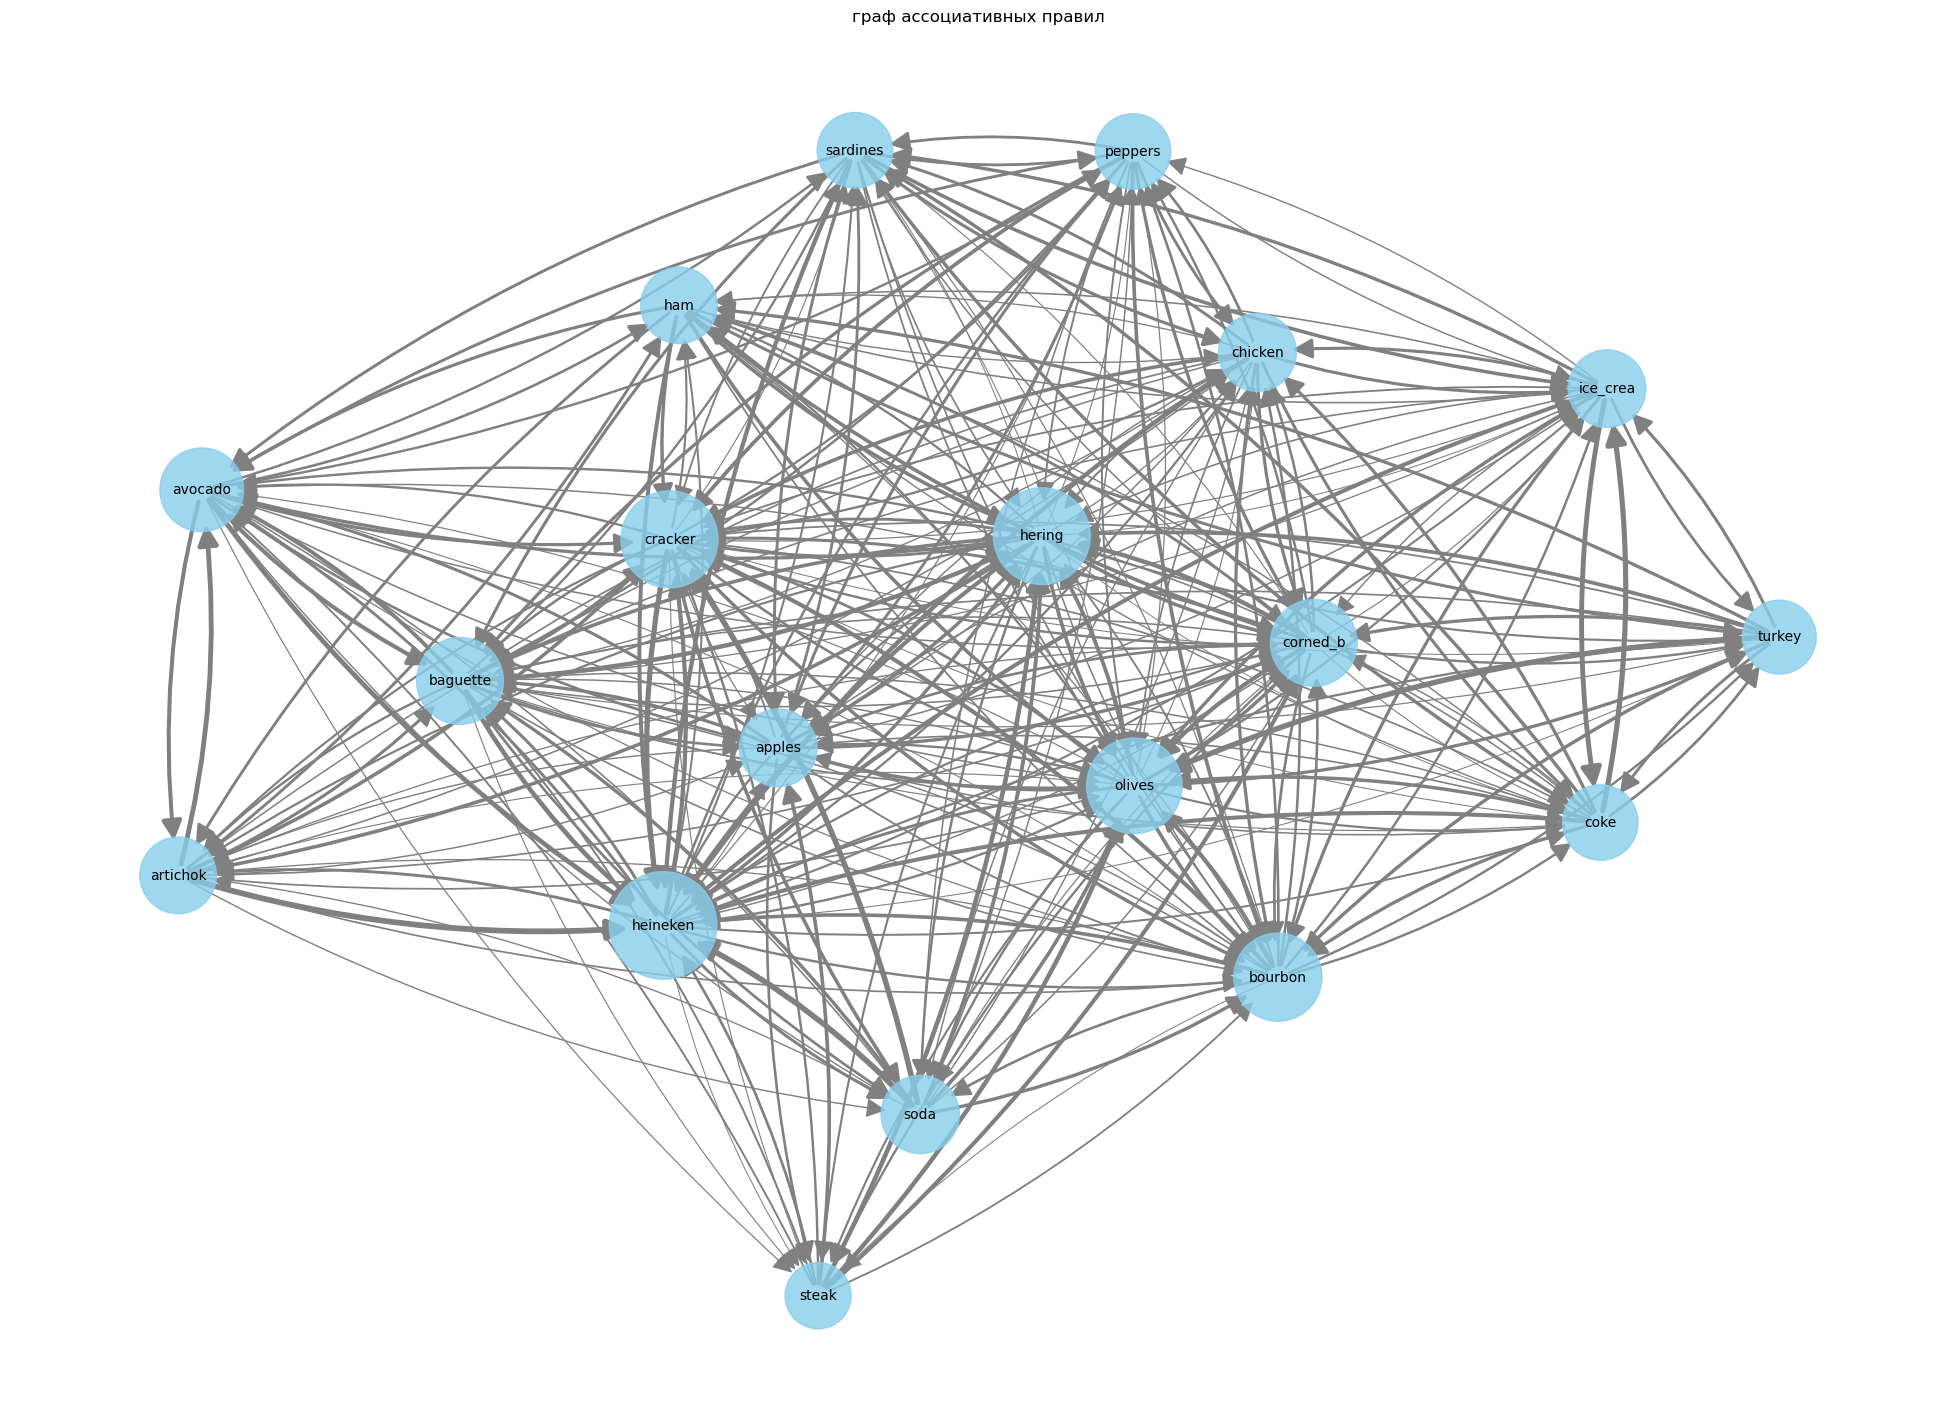

In [45]:
item_support_dict = {}
for _, row in frequent_itemsets[frequent_itemsets['length'] == 1].iterrows():
    item_name = list(row['itemsets'])[0]
    item_support_dict[item_name] = row['support']

G = nx.DiGraph()
for idx, row in rules_2.iterrows():
    G.add_edge(row['from'], row['to'], weight=row['confidence'])

plt.figure(figsize=(25, 18))
pos = nx.spring_layout(G, k=1.5) #расположение узлов
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()] #толщина линий зависит от confidence
node_sizes = [item_support_dict.get(node, 0.05) * 10000 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, 
                       width=weights, 
                       edge_color='gray', 
                       arrowsize=30, 
                       min_target_margin=25, 
                       connectionstyle='arc3, rad=0.1')
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif') #названия товаров
plt.title("граф ассоциативных правил")
plt.axis('off')
plt.show()

## 6. Расчет мер центральности

In [46]:
#рассчитываем меры HITS (Hubs and Authorities)
hubs, authorities = nx.hits(G) #узел получает высокий статус Hub, если он указывает на узлы с высоким статусом Authority (товары, которые все хотят купить)

#элемент с самой высокой мерой Hub
max_hub_item = max(hubs, key=hubs.get)
max_hub_value = hubs[max_hub_item]

#мера для продукта (turkey)
turkey_hub_value = hubs.get('turkey', 0)

print(f"Элемент с максимальным Hub Score: {max_hub_item} ({max_hub_value:.4f})")
print(f"Hub Score для 'turkey': {turkey_hub_value:.4f}")


Элемент с максимальным Hub Score: soda (0.0565)
Hub Score для 'turkey': 0.0479


In [47]:
print(f'Элемент с максимальным authority score: {max(authorities, key=authorities.get)} = {authorities[max(authorities, key=authorities.get)]}')

Элемент с максимальным authority score: heineken = 0.10035604229719082


## 7. Построение линейной проекции набора данных с помощью Non-Negative Matrix Factorization (NMF)
Матрица транзакций содержит только неотрицательные значения (0 и 1), что является идеальным условием для применения NMF.

In [48]:
pivot = pd.crosstab(df['CUSTOMER'], df['PRODUCT'])
turkey_mask = pivot['turkey'] > 0
nmf = NMF(n_components=2, init='random', random_state=42) #инициализация модели
W = nmf.fit_transform(pivot)

In [49]:
components = nmf.components_
components_df = pd.DataFrame(
    components.T,
    index=pivot.columns,
    columns=['Компонента_1', 'Компонента_2']
)
#полученные компоненты
print(components_df['Компонента_1'].sort_values(ascending=False).head(10))
print(components_df['Компонента_2'].sort_values(ascending=False).head(10))


PRODUCT
olives      1.101788
corned_b    0.828815
bourbon     0.764071
turkey      0.691790
ice_crea    0.625349
coke        0.594786
hering      0.482977
apples      0.436220
chicken     0.415568
steak       0.407158
Name: Компонента_1, dtype: float64
PRODUCT
heineken    1.313509
cracker     0.964565
baguette    0.947228
avocado     0.919179
artichok    0.780680
hering      0.690185
soda        0.641027
sardines    0.382615
peppers     0.345933
ham         0.318308
Name: Компонента_2, dtype: float64


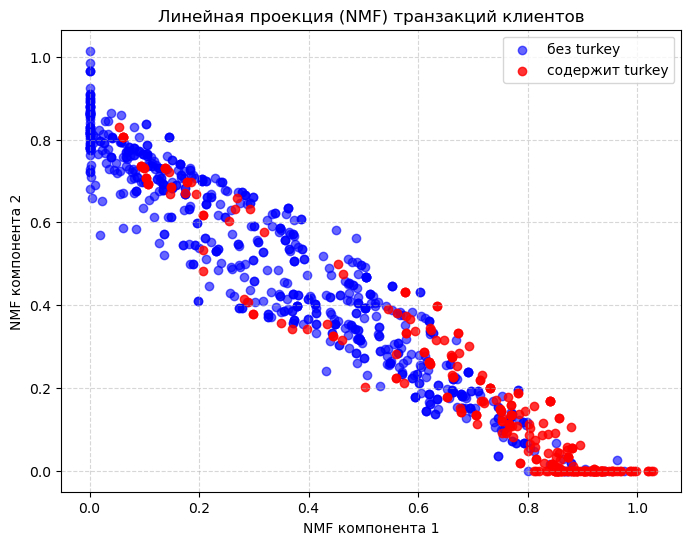

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(W[~turkey_mask, 0], W[~turkey_mask, 1],
            color='blue', alpha=0.6, label='без turkey') #не покупали индейку
plt.scatter(W[turkey_mask, 0], W[turkey_mask, 1],
            color='red', alpha=0.8, label='содержит turkey') #покупали индейку
plt.xlabel('NMF компонента 1')
plt.ylabel('NMF компонента 2')
plt.title('Линейная проекция (NMF) транзакций клиентов')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Можно сделать вывод, что покупатели индейки также часто покупают товары из Компоненты 1. Покупка индейки коррелирует с определенными линейными комбинациями других товаров, но не формирует изолированную группу в линейном пространстве признаков.

## 8. Построение нелинейной проекции с помощью t-SNE (t-Distributed Stochastic Neighbor Embedding)
Метод предназначен для визуализации высокоразмерных данных, сохраняя локальные структуры соседства точек, что позволяет выявлять сложные нелинейные зависимости.

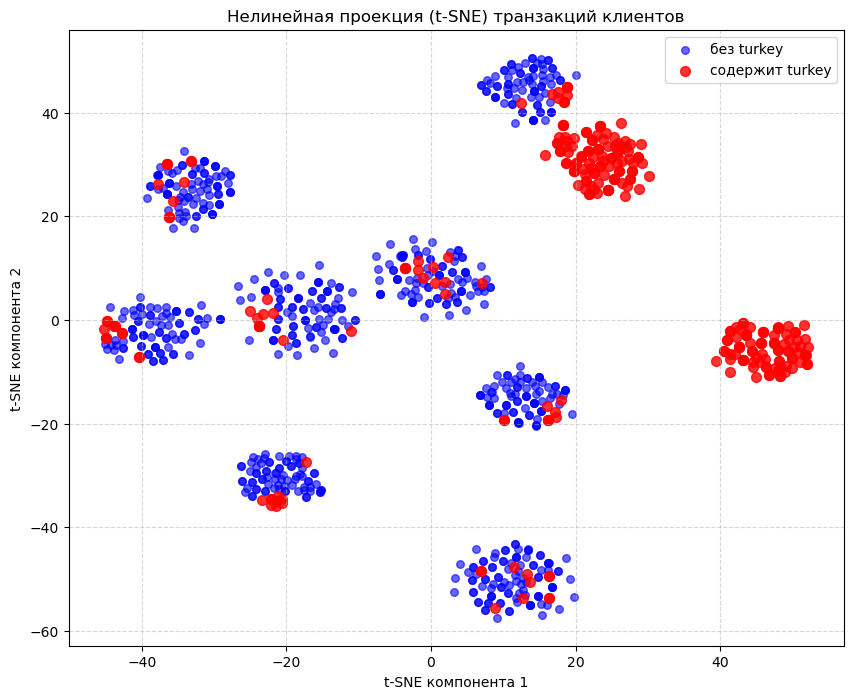

In [51]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30) # для баланса между локальной и глобальной структурами
X_proj = tsne.fit_transform(pivot)
plt.figure(figsize=(10, 8))
plt.scatter(X_proj[~turkey_mask, 0], X_proj[~turkey_mask, 1],
            color='blue', alpha=0.6, s=30, label='без turkey')
plt.scatter(X_proj[turkey_mask, 0], X_proj[turkey_mask, 1],
            color='red', alpha=0.8, s=50, label='содержит turkey')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('Нелинейная проекция (t-SNE) транзакций клиентов')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

t-SNE четко два отдельных кластера, содержащих транзакции с индейкой. Это указывает на то, что существуют две разные группы покупателей, приобретающих индейку, но имеющие существенно разные профили покупок остальных товаров.

# 9. Отбор независимых переменных (VarClus)
 Целью было сократить количество переменных до 7 независимых представителей, каждый из которых максимально хорошо представляет свой кластер коррелирующих товаров.

In [54]:
metod = VarClusHi(pivot, maxeigval2=0.9, maxclus=7)
metod.varclus()

results = metod.rsquare.copy()
results['RS_Ratio'] = (1 - results.RS_Own) / (1 - results.RS_NC)
answer = results.loc[results.groupby('Cluster')['RS_Ratio'].idxmin()]

print(answer[['Cluster', 'Variable', 'RS_Ratio']])

    Cluster  Variable  RS_Ratio
1         0    olives  0.401515
4         1  ice_crea  0.234108
7         2  heineken  0.396626
11        3    hering  0.611567
14        4      soda  0.331606
16        5  bordeaux  0.000000
18        6   avocado  0.401529


# Выводы
Были успешно реализованы все этапы анализа транзакционных данных.

1. С помощью алгоритма FP-Growth при минимальной поддержке 6 % найдены все частые наборы товаров (frequent itemsets) размером до 4 элементов включительно. 
2. Среди всех частых наборов, содержащих индейку (turkey), самый большой по размеру эпизод состоит из 5 продуктов:
{ham, corned_b, turkey, olives, hering} с поддержкой 10.19 %.
3. На основе частых эпизодов с минимальной достоверностью (confidence) 10 % сгенерированы ассоциативные правила.
Правило с максимальным lift, содержащее продукт turkey в левой части:
{coke, turkey} → {ice_crea, olives, bourbon}
Support: 9.39 %
Confidence: 78.99 %
Lift: 7.32
Покупатели, которые приобретают колу и индейку, с вероятностью почти 79 % также берут мороженое, оливки и бурбон. Значение lift 7.32 означает, что данная комбинация встречается в 7.32 раза чаще, чем можно было бы ожидать при независимом выборе товаров. Это указывает на очень сильную и устойчивую ассоциацию в поведении покупателей.

4. Построен направленный граф двухместных ассоциативных правил.
С помощью алгоритма HITS рассчитаны меры центральности Hub.
Товар с наивысшим Hub Score: soda (0.0565)
Hub Score для продукта turkey: 0.0479 (достаточно высокий показатель, товар активно «рекомендует» другие продукты). Покупка газированной воды (soda) часто ведет к покупке других востребованных товаров. Высокое значение authority score = 0.1 у пива (heineken) говорит о том, что данный товар часто покупают после взаимодействия с товарами-хабами, а также он выступает в роли конечной точки в цепочке покупок.

5. В то время как линейный метод (NMF) показал размытое распределение покупателей индейки, t-SNE четко выделил два отдельных кластера, содержащих транзакции с индейкой (turkey). Это указывает на то, что существуют две разные группы покупателей, приобретающих индейку, но имеющие существенно разные профили покупок остальных товаров.

6. Индейка не вошла в итоговый список лидеров. Это означает, что с точки зрения статистической структуры данных (корреляционных связей), информация о покупке индейки дублируется или сильно коррелирует с другими товарами, либо она не является сильным лидером в своем кластере.
